<a href="https://colab.research.google.com/github/jananiksaagash-rgb/AppliedAI/blob/main/Ex12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Upload known images (kalam.jpg, einstein.jpg etc.)


Saving Business Photo.png to Business Photo.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
 Known faces stored: ['Business Photo']
 Upload test image


Saving Business Photo.png to Business Photo (1).png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step


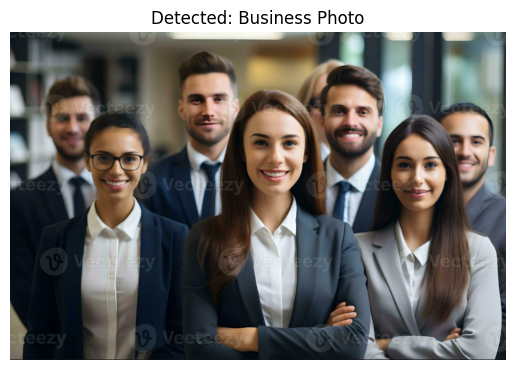

 Person: Business Photo


In [7]:
# ==============================
# FACE RECOGNITION USING FACENET
# COLAB WORKING VERSION
# ==============================

!pip install keras-facenet opencv-python-headless

import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab import files
from keras_facenet import FaceNet

# ------------------------------
# 1. Initialize FaceNet
# ------------------------------
embedder = FaceNet()

# ------------------------------
# 2. Face Extraction (OpenCV instead of MTCNN)
# ------------------------------
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

def extract_face(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)

    if len(faces) == 0:
        return None

    x, y, w, h = faces[0]
    face = img[y:y+h, x:x+w]
    face = cv2.resize(face, (160, 160))

    return face

# ------------------------------
# 3. Get Face Embedding (FaceNet)
# ------------------------------
def get_embedding(face):
    face = face.astype('float32')
    face = np.expand_dims(face, axis=0)
    embedding = embedder.embeddings(face)
    return embedding[0]

# ------------------------------
# 4. Store Known Faces
# ------------------------------
known_faces = {}

print(" Upload known images (kalam.jpg, einstein.jpg etc.)")
uploaded = files.upload()

for fn in uploaded.keys():
    img = cv2.imread(fn)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    face = extract_face(img)

    if face is not None:
        known_faces[fn.split('.')[0]] = get_embedding(face)

print(" Known faces stored:", list(known_faces.keys()))

# ------------------------------
# 5. Upload Test Image
# ------------------------------
print(" Upload test image")
uploaded = files.upload()

# ------------------------------
# 6. Prediction
# ------------------------------
for fn in uploaded.keys():

    img = cv2.imread(fn)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    face = extract_face(img)

    if face is None:
        print(" No face detected")
        continue

    test_embedding = get_embedding(face)

    # Compare
    min_dist = float("inf")
    identity = "Unknown"

    for name, emb in known_faces.items():
        dist = np.linalg.norm(emb - test_embedding)

        if dist < min_dist:
            min_dist = dist
            identity = name

    # Threshold
    if min_dist > 0.9:
        identity = "Unknown"

    # Show result
    plt.imshow(img)
    plt.title(f"Detected: {identity}")
    plt.axis("off")
    plt.show()

    print(" Person:", identity)